# DIABETES PREDICTION MODEL ##
This project builds a machine learning model to predict whether a patient has diabetes or not based on the clinical parameters.

**Dataset:**
- Pima Indians Diabetes Dataset(768 rows and 9 columns).
- Contains data only for females aged 21 or older.

**Models Used:** Decision Tree Classifier, Random Forest Classifier

**Final Accuracy:** 77.27%

Made by Saket Gupta | RNT Medical College, Udaipur

In [1]:
import pandas as pd
import numpy as np

In [2]:
patient_data = pd.read_csv("/content/diabetes.csv")


In [3]:
#First look over the dataframe.
patient_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Details About The Columns**
- **PREGNANCIES:** Number of times pregnant
- **Glucose:** Plasma glucose concentration at 2 hours in an OGTT
- **Blood pressure:** Diastolic blood pressure (in mm Hg)
- **Skin Thickness:** Triceps skin fold thickness(mm)
- **Insulin:** 2-Hour serumn insulin(mu/ml)
- **BMI:** Body Mass Index
- **Diabetes Pedigree:** Genetic Susceptibility for Diabetes.
- **Age:** Age in years.
- **Outcome:** Binary outcomes, "0" for negative and "1" for positive.




In [4]:
patient_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##DATA CLEANING
- In this section  columns like glucose, blood pressure, skin thickness, insulin and  bmi shows zero which is not a possible value.

- Here, to calculate total of such data, I have replaced the "0", with NAN's.

- Since the columns Insulin and SkinThickess has a huge chunk of missing data, its better to drop those columns.

- Columns with remaning NAN's are filled by there median values.


In [5]:
# Replace these "0" values with NAN's

cols_with_zeros = ['Glucose', 'BloodPressure',
                   'SkinThickness', 'Insulin', 'BMI']

patient_data[cols_with_zeros] = patient_data[cols_with_zeros].replace(0, np.nan)

patient_data.isnull().sum()


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
# Drop Insulin and SkinThickness column
patient_data = patient_data.drop(columns=['Insulin', 'SkinThickness'])

# Fill the  remaining missing with median in remaining columns
cols_to_fill = ['Glucose', 'BloodPressure', 'BMI']

patient_data[cols_to_fill] = patient_data[cols_to_fill].fillna(
    patient_data[cols_to_fill].median()
)

# Verifying
patient_data.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##Creating a ML model for the outcome ("y") prediction using features in ("X")

In [7]:
y = patient_data.Outcome

features =["Pregnancies","Glucose", "BloodPressure", "BMI", "DiabetesPedigreeFunction", "Age"]
X = patient_data[features]

**First Model using Decision Tree**

 A Decision Tree is a supervised machine learning algorithm that predicts an outcome by splitting data into branches based on feature values, forming a tree-like structure of decision rules.

 **Accuracy:** 76.623%

In [8]:
# Splitting the data into training and testing data with a ration of 80/20
from sklearn.model_selection import train_test_split
train_X, val_X , train_y , val_y = train_test_split(X, y , random_state = 42, test_size =  0.2, train_size = 0.8 )
# training the data
from sklearn.tree import DecisionTreeClassifier

trained_data = DecisionTreeClassifier(random_state = 42)
trained_data.fit(train_X, train_y)

# verifying using the remaining 20% as testing data

diab_predict =  trained_data.predict(val_X)

# finding the mean _absolute error for the trained model, using test data prediction
from sklearn.metrics import accuracy_score


accuracy= accuracy_score(val_y , diab_predict)

print ("Accuracy = ", accuracy*100,"%")

Accuracy =  76.62337662337663 %


**Second Model using Random Forest Classifier**

 A Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple decision trees, each trained on random subsets of the data and features, to improve accuracy and reduce overfitting.

 **Accuracy:** 77.272%

In [9]:
# Splitting the data into training and testing data with a ration of 80/20 ,
"""now using Random Forest Classifier"""
from sklearn.model_selection import train_test_split
train_X, val_X , train_y , val_y = train_test_split(X, y , random_state = 42, test_size =  0.2, train_size = 0.8 )
# training the data
from sklearn.ensemble import RandomForestClassifier

trained_data = RandomForestClassifier(random_state = 42)
trained_data.fit(train_X, train_y)

# verifying using the remaining 20% as testing data

diab_predict =  trained_data.predict(val_X)

# finding the mean _absolute error for the trained model, using test data prediction
from sklearn.metrics import accuracy_score


accuracy= accuracy_score(val_y , diab_predict)

print ("Accuracy = ", accuracy*100,"%")
#Random Forest Classifier has  improved the accuracy slightly by about 0.65%

Accuracy =  77.27272727272727 %


**Analysing model performance using CONFUSION MATRIX**

**Confusion Matrix:**
- It is used to evaluate the accuracy of the classification.
- Here, it used for identifying false negative and false positive cases, as both are extremely dangerous.
- In false negative, basically the patient suffers from diabetes but it is not diagnosed, which can lead to chronic complications of the DM.
- In false positive, more dangerous as antidiabetic medication(Insulin, Metformin, etc.) can cause severe hypoglycemia, and it could be fatal.

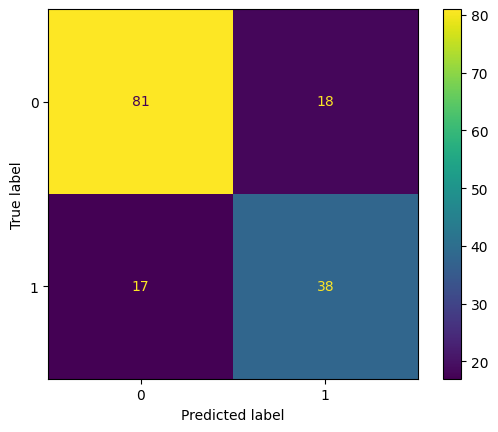

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
a = confusion_matrix(val_y, diab_predict)
display = ConfusionMatrixDisplay(confusion_matrix = a)
display.plot()
plt.show()
# here
#   81 - true negative (correctly predicted no diabetes)
#   18 - false positive
#   17 - false negative
#   38 - true positive



**Feature Importance**

 Checking for which features mattered most for prediction
 using "feature_importances_" and plotting a Bar Graph.

 It gives the outcome as Diabetes is most dependent on Plasma Glucose(about 30%) and BMI(about 20%).





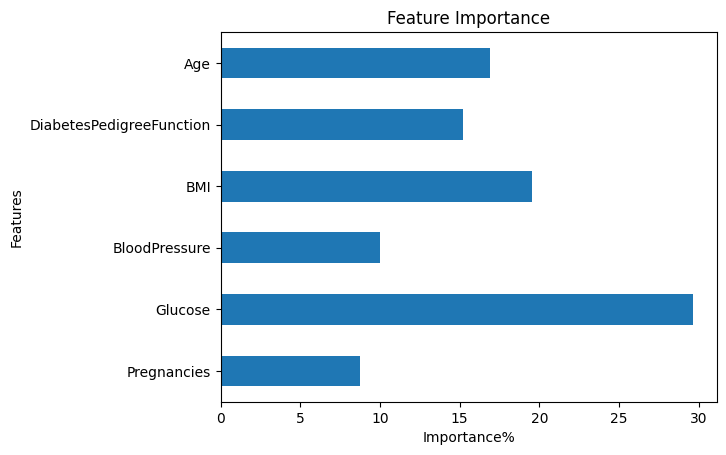

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.Series(trained_data.feature_importances_, index = X.columns)
feature_importance = feature_importance/feature_importance.sum() *100
feature_importance.sort_values()
feature_importance.plot(kind= 'barh')
plt.title("Feature Importance")
plt.xlabel("Importance%")
plt.ylabel("Features")
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y , test_size=0.3, random_state=42)
# Train logistic regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)


In [14]:
# Precision, Recall, F1 Score for each class
print("Precision (Per Class):", precision_score(y_test, y_pred, average=None))
print("Recall (Per Class):", recall_score(y_test, y_pred, average=None))
print("F1 Score (Per Class):", f1_score(y_test, y_pred, average=None))


Precision (Per Class): [0.78846154 0.62666667]
Recall (Per Class): [0.81456954 0.5875    ]
F1 Score (Per Class): [0.80130293 0.60645161]


In [15]:
print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))
print("Weighted Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))
print("Weighted Recall:", recall_score(y_test, y_pred, average='weighted'))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Macro Precision: 0.7075641025641026
Weighted Precision: 0.7324286824286824
Macro Recall: 0.7010347682119206
Weighted Recall: 0.7359307359307359
Macro F1 Score: 0.7038772722496585
Weighted F1 Score: 0.7338219554254019


In [19]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(trained_data,X ,y, cv = 5)
print("Cross Validation Score is :", np.mean(score))

Cross Validation Score is : 0.7617689500042442
